In [1]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

# Display Settings
pd.set_option("display.max_columns", None)

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Regression Models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    AdaBoostRegressor,
    ExtraTreesRegressor
)

# Optional (Install xgboost if not already installed)
from xgboost import XGBRegressor

# Save Model
import joblib

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
# Load Dataset
df = pd.read_csv(r"C:\Users\Kanth\Downloads\Student_performance_data _.csv")

# Display first 5 rows
df.head()

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0


In [3]:
# Shape of the dataset
print("Shape of Dataset:", df.shape)

Shape of Dataset: (2392, 15)


In [4]:
# Column names
df.columns

Index(['StudentID', 'Age', 'Gender', 'Ethnicity', 'ParentalEducation',
       'StudyTimeWeekly', 'Absences', 'Tutoring', 'ParentalSupport',
       'Extracurricular', 'Sports', 'Music', 'Volunteering', 'GPA',
       'GradeClass'],
      dtype='object')

In [5]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2392 entries, 0 to 2391
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   StudentID          2392 non-null   int64  
 1   Age                2392 non-null   int64  
 2   Gender             2392 non-null   int64  
 3   Ethnicity          2392 non-null   int64  
 4   ParentalEducation  2392 non-null   int64  
 5   StudyTimeWeekly    2392 non-null   float64
 6   Absences           2392 non-null   int64  
 7   Tutoring           2392 non-null   int64  
 8   ParentalSupport    2392 non-null   int64  
 9   Extracurricular    2392 non-null   int64  
 10  Sports             2392 non-null   int64  
 11  Music              2392 non-null   int64  
 12  Volunteering       2392 non-null   int64  
 13  GPA                2392 non-null   float64
 14  GradeClass         2392 non-null   float64
dtypes: float64(3), int64(12)
memory usage: 280.4 KB


In [6]:
# Statistical summary
df.describe()

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
count,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000
mean,2196.500000,16.468645,0.510870,0.877508,1.746237,9.771992,14.541388,0.301421,2.122074,0.383361,0.303512,0.196906,0.157191,1.906186,2.983696
std,690.655244,1.123798,0.499986,1.028476,1.000411,5.652774,8.467417,0.458971,1.122813,0.486307,0.459870,0.397744,0.364057,0.915156,1.233908
min,1001.000000,15.000000,0.000000,0.000000,0.000000,0.001057,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1598.750000,15.000000,0.000000,0.000000,1.000000,5.043079,7.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.174803,2.000000
50%,2196.500000,16.000000,1.000000,0.000000,2.000000,9.705363,15.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,1.893393,4.000000
75%,2794.250000,17.000000,1.000000,2.000000,2.000000,14.408410,22.000000,1.000000,3.000000,1.000000,1.000000,0.000000,0.000000,2.622216,4.000000
max,3392.000000,18.000000,1.000000,3.000000,4.000000,19.978094,29.000000,1.000000,4.000000,1.000000,1.000000,1.000000,1.000000,4.000000,4.000000


In [7]:
# Check missing values
df.isnull().sum()

StudentID            0
Age                  0
Gender               0
Ethnicity            0
ParentalEducation    0
StudyTimeWeekly      0
Absences             0
Tutoring             0
ParentalSupport      0
Extracurricular      0
Sports               0
Music                0
Volunteering         0
GPA                  0
GradeClass           0
dtype: int64

In [8]:
# Check duplicate records
df.duplicated().sum()

np.int64(0)

In [9]:
df.dtypes

StudentID              int64
Age                    int64
Gender                 int64
Ethnicity              int64
ParentalEducation      int64
StudyTimeWeekly      float64
Absences               int64
Tutoring               int64
ParentalSupport        int64
Extracurricular        int64
Sports                 int64
Music                  int64
Volunteering           int64
GPA                  float64
GradeClass           float64
dtype: object

In [12]:
# Numerical and Categorical Columns
numerical_columns = df.select_dtypes(include=['int64','float64']).columns

print("Numerical Columns")
print(numerical_columns)

Numerical Columns
Index(['StudentID', 'Age', 'Gender', 'Ethnicity', 'ParentalEducation',
       'StudyTimeWeekly', 'Absences', 'Tutoring', 'ParentalSupport',
       'Extracurricular', 'Sports', 'Music', 'Volunteering', 'GPA',
       'GradeClass'],
      dtype='object')


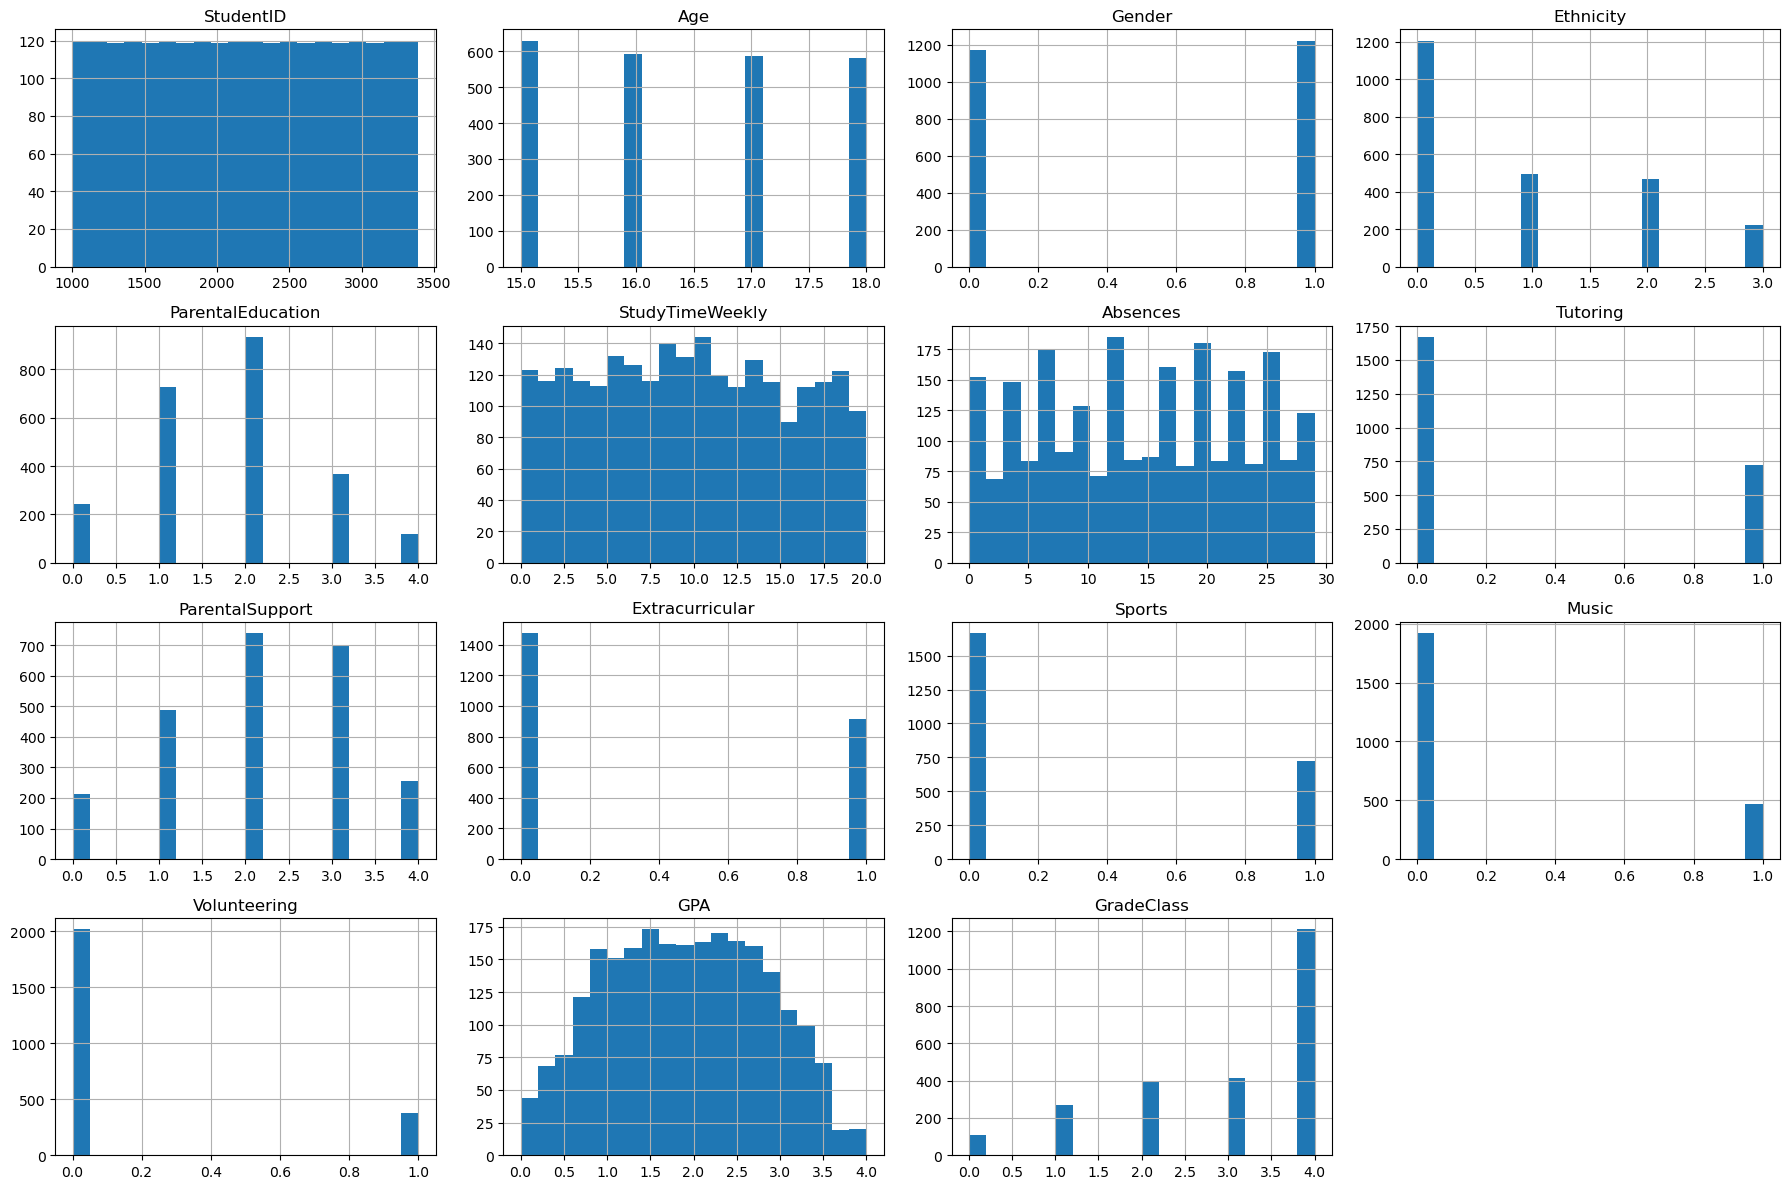

In [13]:
# Distribution of Numerical Features
df[numerical_columns].hist(figsize=(18,12), bins=20)

plt.tight_layout()

plt.show()

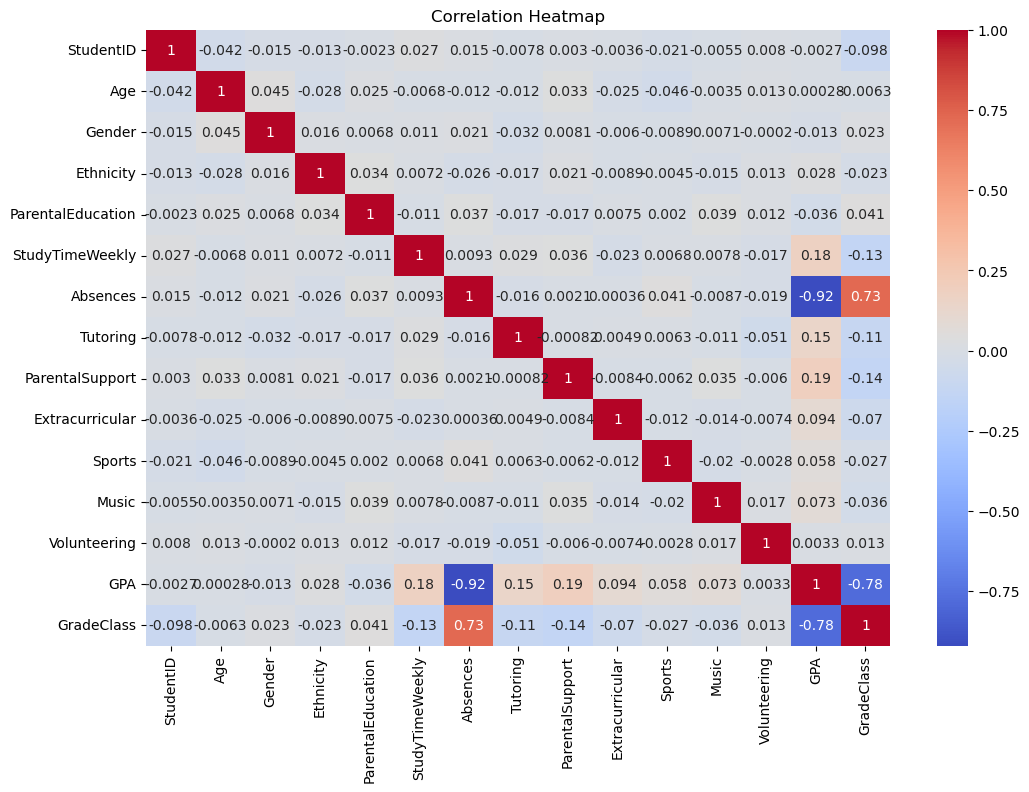

In [14]:
# Correlation Heatmap
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

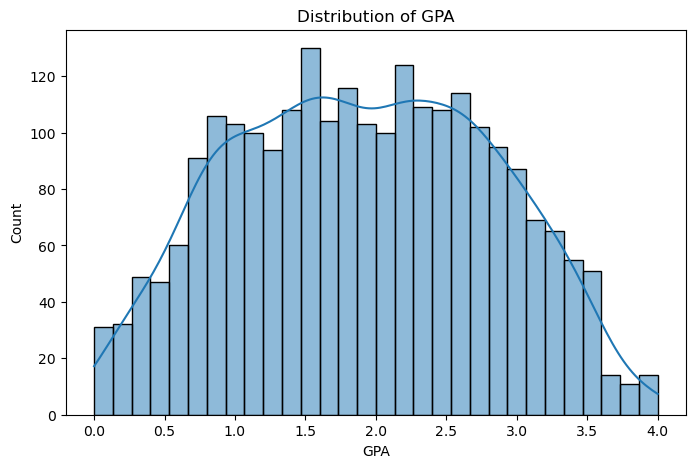

In [15]:
# GPA Distribution
plt.figure(figsize=(8,5))

sns.histplot(df["GPA"], bins=30, kde=True)

plt.title("Distribution of GPA")

plt.xlabel("GPA")

plt.show()

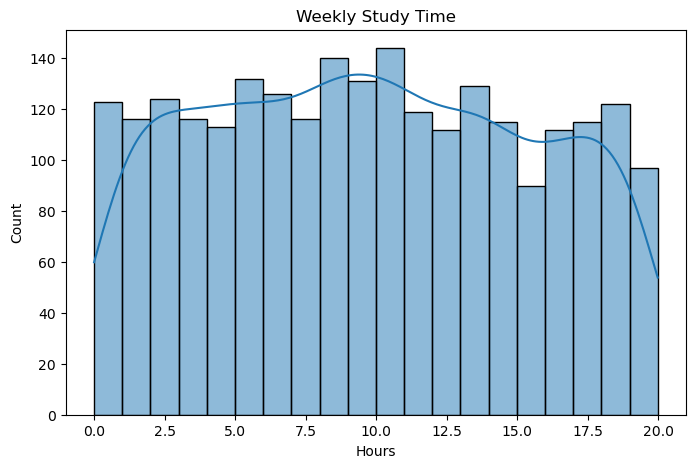

In [16]:
# Study Time Distribution
plt.figure(figsize=(8,5))

sns.histplot(df["StudyTimeWeekly"], bins=20, kde=True)

plt.title("Weekly Study Time")

plt.xlabel("Hours")

plt.show()

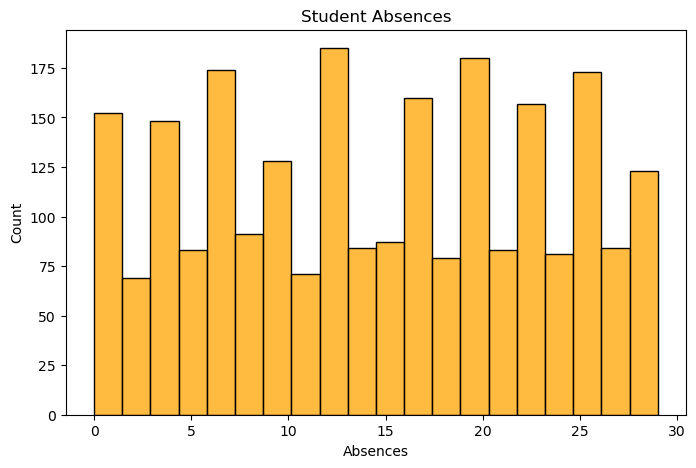

In [17]:
# Absence Distribution
plt.figure(figsize=(8,5))

sns.histplot(df["Absences"], bins=20, color="orange")

plt.title("Student Absences")

plt.show()

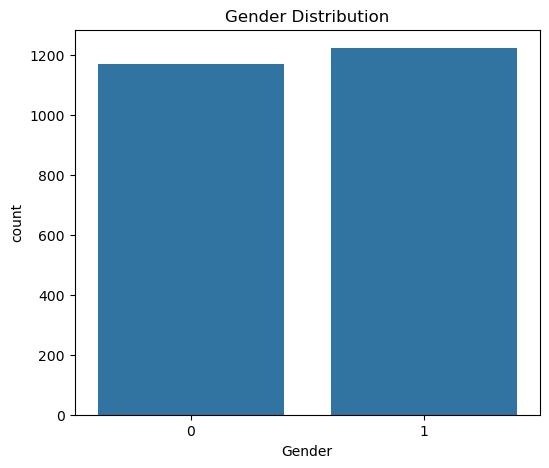

In [18]:
# Gender Distribution
plt.figure(figsize=(6,5))

sns.countplot(x="Gender", data=df)

plt.title("Gender Distribution")

plt.show()

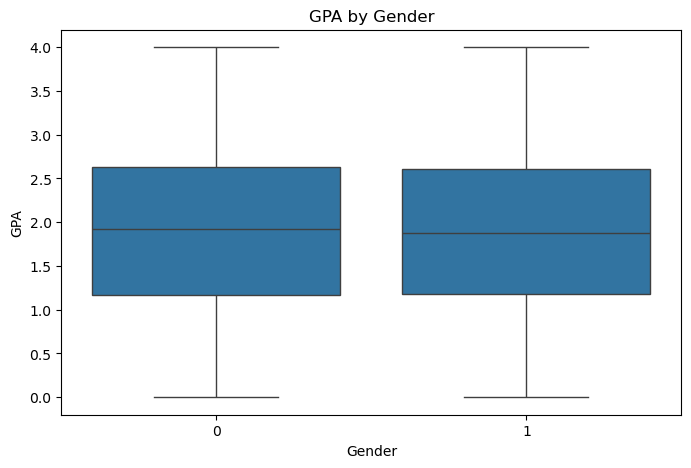

In [19]:
# GPA by Gender
plt.figure(figsize=(8,5))

sns.boxplot(x="Gender",
            y="GPA",
            data=df)

plt.title("GPA by Gender")

plt.show()

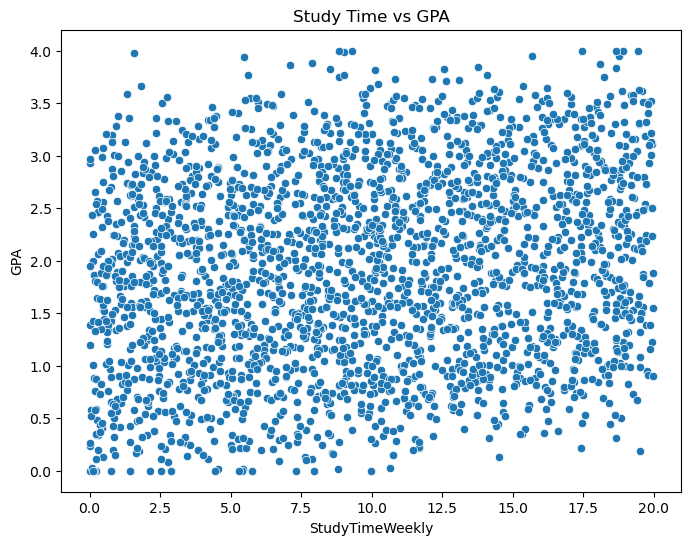

In [21]:
# Study Time vs GPA
plt.figure(figsize=(8,6))

sns.scatterplot(x="StudyTimeWeekly",
                y="GPA",
                data=df)

plt.title("Study Time vs GPA")

plt.show()

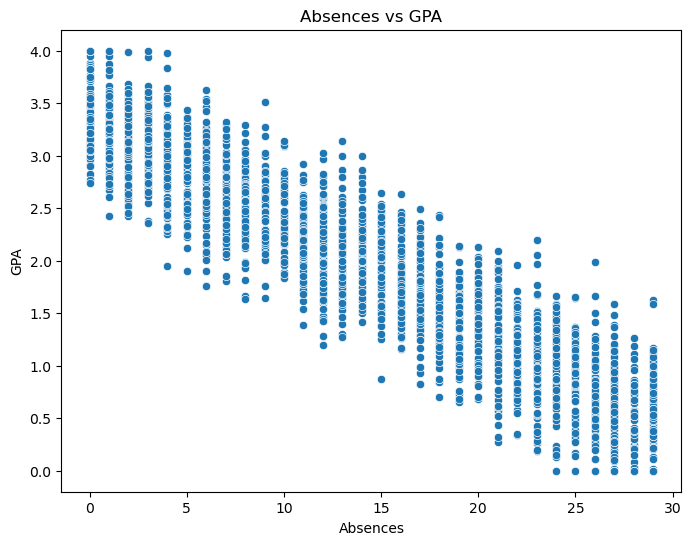

In [22]:
# Absences vs GPA
plt.figure(figsize=(8,6))

sns.scatterplot(x="Absences",
                y="GPA",
                data=df)

plt.title("Absences vs GPA")

plt.show()

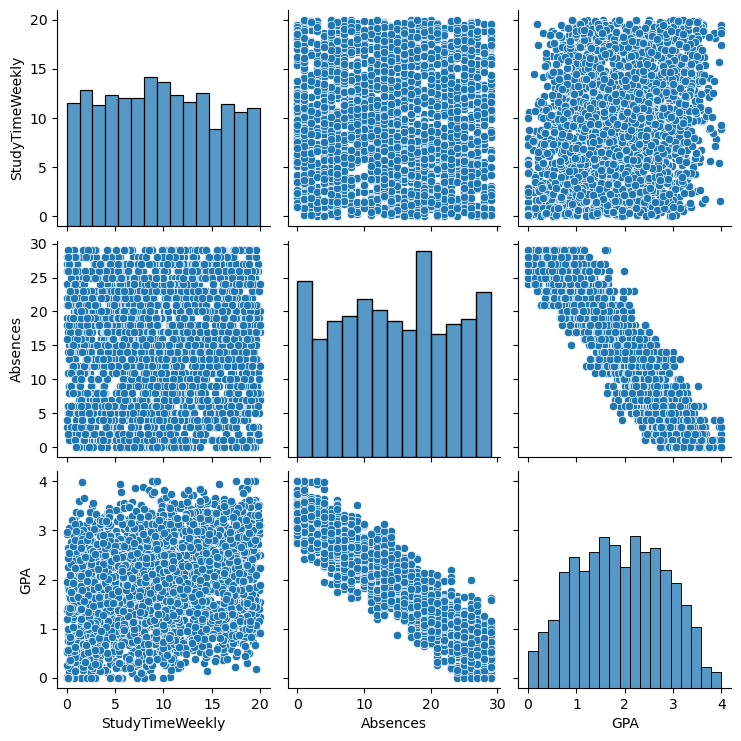

In [23]:
# Pair Plot
sns.pairplot(
    df[["StudyTimeWeekly",
        "Absences",
        "GPA"]]
)

plt.show()

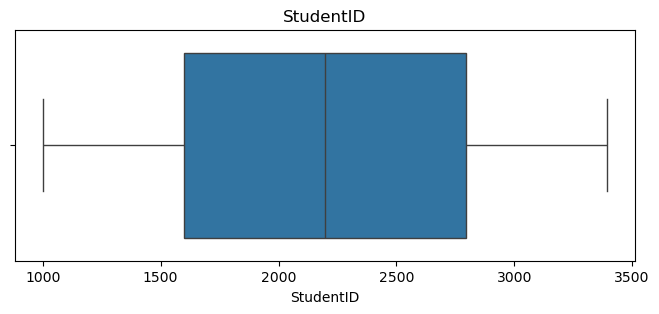

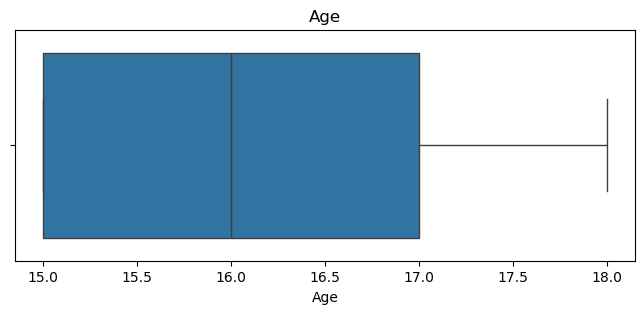

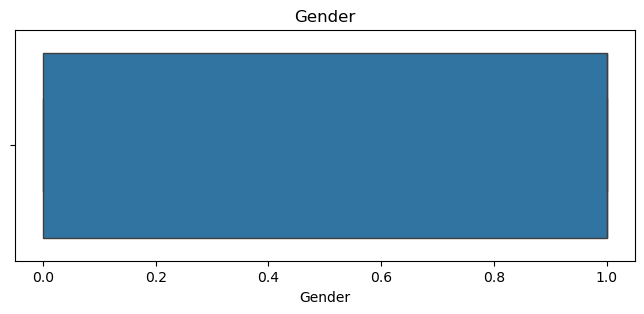

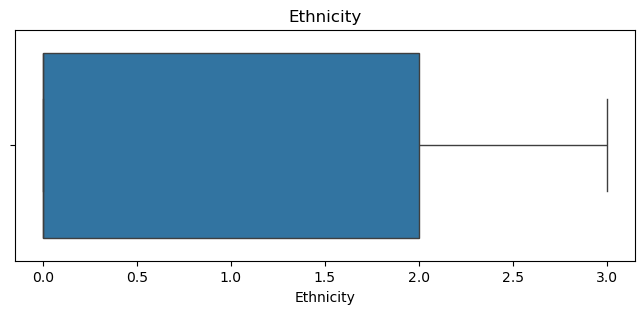

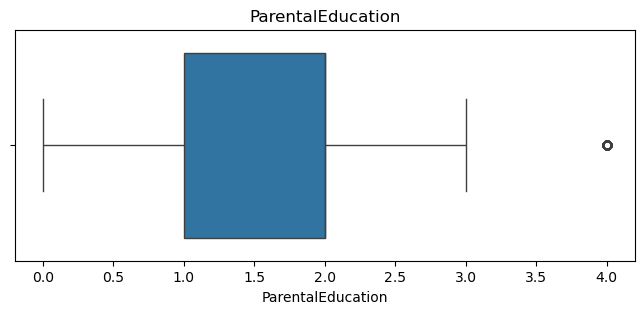

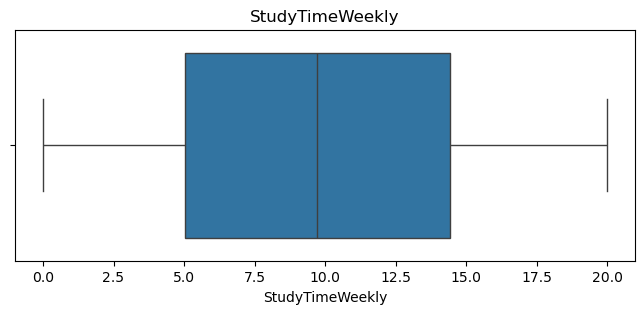

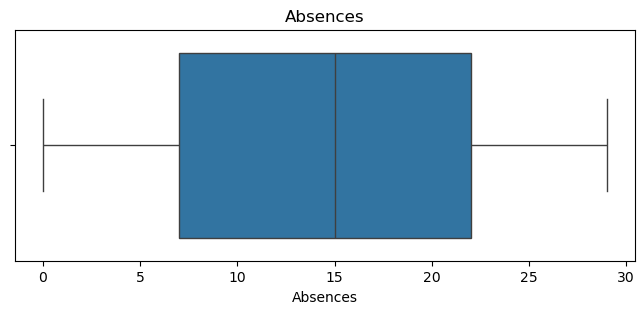

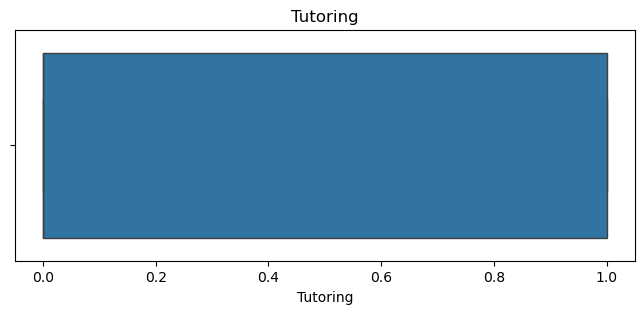

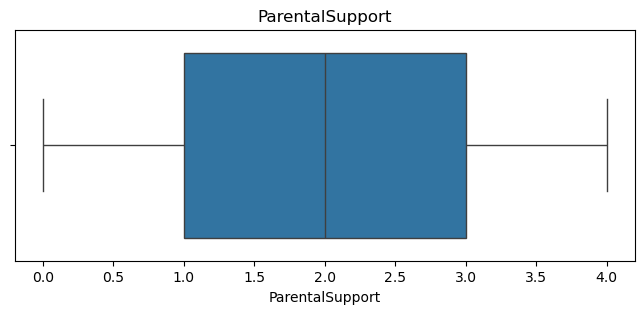

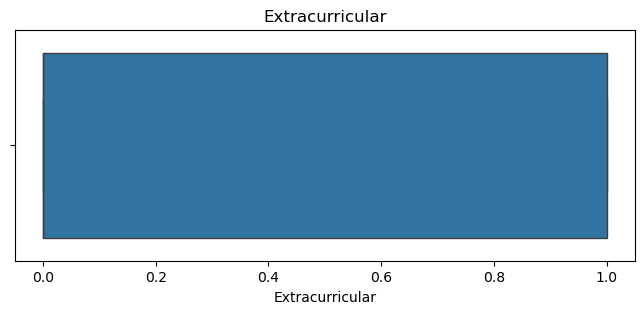

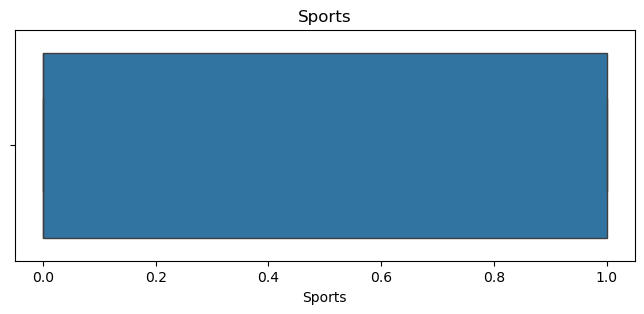

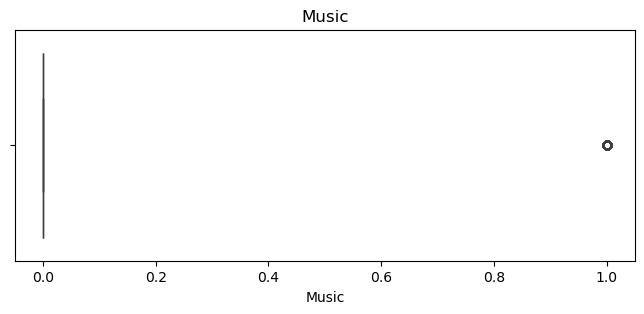

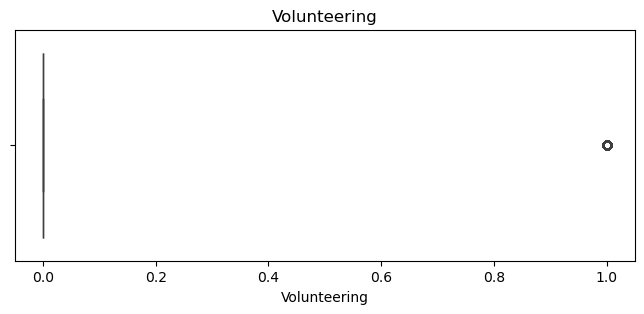

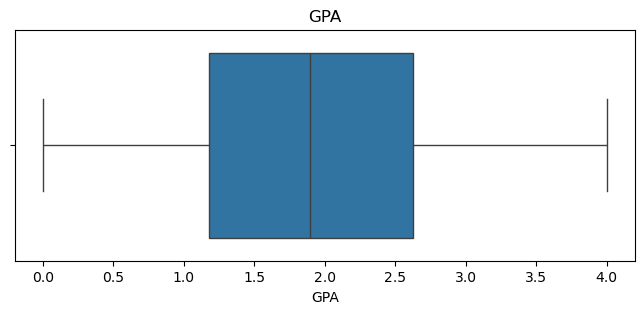

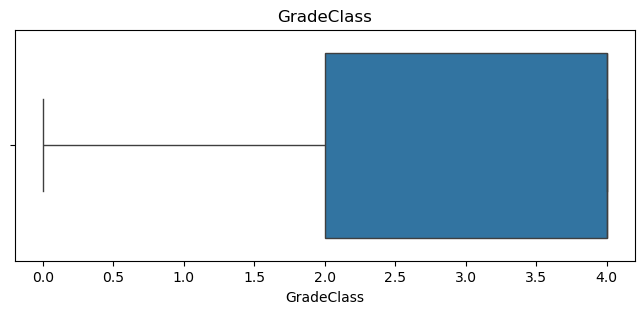

In [24]:
# Boxplots for Outlier Detection
for col in numerical_columns:

    plt.figure(figsize=(8,3))

    sns.boxplot(x=df[col])

    plt.title(col)

    plt.show()

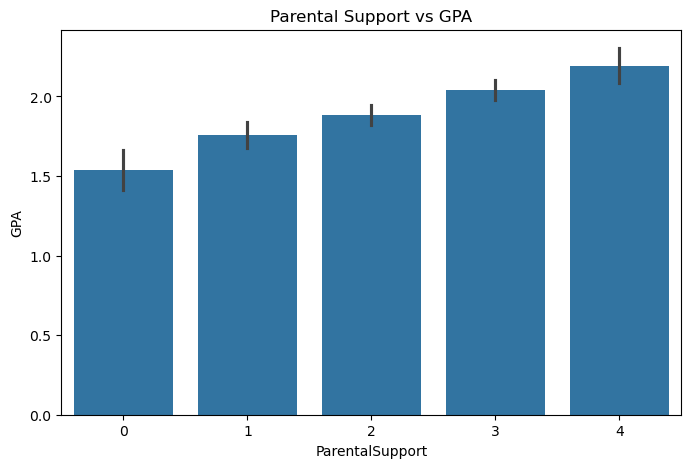

In [25]:
# Average GPA by Parental Support
plt.figure(figsize=(8,5))

sns.barplot(x="ParentalSupport",
            y="GPA",
            data=df)

plt.title("Parental Support vs GPA")

plt.show()

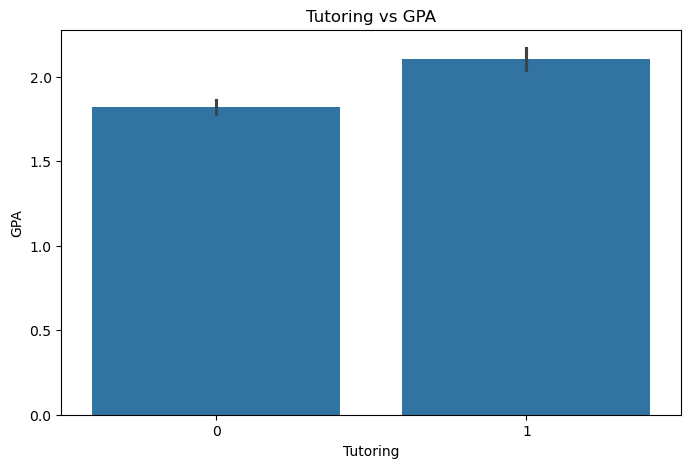

In [26]:
# Average GPA by Tutoring
plt.figure(figsize=(8,5))

sns.barplot(x="Tutoring",
            y="GPA",
            data=df)

plt.title("Tutoring vs GPA")

plt.show()

In [27]:
# Remove Unnecessary Columns

df.drop("StudentID", axis=1, inplace=True)

df.head()

,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0
1,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0
2,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0
3,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0
4,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0


In [28]:
# Feature Engineering
df["StudyEfficiency"] = df["StudyTimeWeekly"] / (df["Absences"] + 1)

In [29]:
# Academic Support
df["AcademicSupport"] = df["Tutoring"] + df["ParentalSupport"]

In [30]:
# Activity Score
df["ActivityScore"] = (
    df["Sports"] +
    df["Music"] +
    df["Volunteering"] +
    df["Extracurricular"]
)

In [31]:
# Total Engagement
df["TotalEngagement"] = (
    df["StudyTimeWeekly"] +
    df["ActivityScore"]
)

In [32]:
df.head()

,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass,StudyEfficiency,AcademicSupport,ActivityScore,TotalEngagement
0,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0,2.479215,3,1,20.833723
1,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0,15.408756,1,0,15.408756
2,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0,0.155947,2,0,4.210570
3,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0,0.668589,3,1,11.028829
4,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0,0.259583,4,0,4.672495


In [33]:
# Select Features and Target

X = df.drop("GPA", axis=1)

y = df["GPA"]

In [34]:
# Check Shapes
print("Feature Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Shape : (2392, 17)
Target Shape : (2392,)


In [35]:
# Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42)


In [36]:
# Check Split
print("Training Features :", X_train.shape)
print("Testing Features :", X_test.shape)

print("Training Target :", y_train.shape)
print("Testing Target :", y_test.shape)

Training Features : (1913, 17)
Testing Features : (479, 17)
Training Target : (1913,)
Testing Target : (479,)


In [37]:
# from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

numeric_cols = [
    "Age",
    "StudyTimeWeekly",
    "Absences",
    "StudyEfficiency",
    "AcademicSupport",
    "ActivityScore",
    "TotalEngagement"
]
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

numeric_cols = [
    "Age",
    "StudyTimeWeekly",
    "Absences",
    "StudyEfficiency",
    "AcademicSupport",
    "ActivityScore",
    "TotalEngagement"
]

In [38]:
# Scale Training Data
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_cols] = scaler.fit_transform(
    X_train[numeric_cols]
)

X_test_scaled[numeric_cols] = scaler.transform(
    X_test[numeric_cols]
)

In [39]:
X_train_scaled.head()

,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GradeClass,StudyEfficiency,AcademicSupport,ActivityScore,TotalEngagement
642,1.372851,1,0,4,1.468159,1.105915,1,0,1,1,0,0,4.0,-0.244195,-1.187885,1.132020,1.619536
1752,-0.405858,1,3,2,-1.276773,0.516509,0,1,0,0,0,1,4.0,-0.513361,-1.187885,-0.046192,-1.270203
1401,0.483497,0,2,3,-1.103632,1.223797,0,0,0,0,0,0,4.0,-0.509120,-2.011227,-1.224404,-1.272437
2032,0.483497,1,0,1,1.068117,1.223797,1,2,0,0,0,0,4.0,-0.295941,0.458799,-1.224404,0.876561
990,-0.405858,0,0,0,-1.526524,0.516509,1,2,0,0,1,0,4.0,-0.545231,0.458799,-0.046192,-1.517338


In [40]:
import joblib

joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [41]:
# Import Models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    AdaBoostRegressor,
    ExtraTreesRegressor
)

from xgboost import XGBRegressor

In [42]:
# Create Model Dictionary
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "AdaBoost": AdaBoostRegressor(random_state=42),
    "Extra Trees": ExtraTreesRegressor(random_state=42),
    "XGBoost": XGBRegressor(random_state=42)
}

In [43]:
# Import Evaluation Metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [44]:
# Train All Models
results = []

for name, model in models.items():

    # Train Model
    model.fit(X_train_scaled, y_train)

    # Prediction
    y_pred = model.predict(X_test_scaled)

    # Evaluation
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results.append([name, mae, mse, rmse, r2])

print("Training Completed Successfully!")

Training Completed Successfully!


In [45]:
# Create Results DataFrame
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "MAE",
        "MSE",
        "RMSE",
        "R2 Score"
    ]
)

results_df

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,0.150235,0.035783,0.189163,0.956728
1,Decision Tree,0.238626,0.104172,0.322757,0.874026
2,Random Forest,0.165972,0.048952,0.221250,0.940803
3,Gradient Boosting,0.148123,0.037955,0.194821,0.954101
4,AdaBoost,0.184587,0.054057,0.232502,0.934630
5,Extra Trees,0.159556,0.046098,0.214704,0.944254
6,XGBoost,0.165257,0.046188,0.214913,0.944146


In [46]:
# Sort by Best Model
results_df = results_df.sort_values(
    by="R2 Score",
    ascending=False
)

results_df

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,0.150235,0.035783,0.189163,0.956728
3,Gradient Boosting,0.148123,0.037955,0.194821,0.954101
5,Extra Trees,0.159556,0.046098,0.214704,0.944254
6,XGBoost,0.165257,0.046188,0.214913,0.944146
2,Random Forest,0.165972,0.048952,0.221250,0.940803
4,AdaBoost,0.184587,0.054057,0.232502,0.934630
1,Decision Tree,0.238626,0.104172,0.322757,0.874026


In [47]:
# Display Best Model
best_model_name = results_df.iloc[0]["Model"]

print("Best Model:", best_model_name)

Best Model: Linear Regression


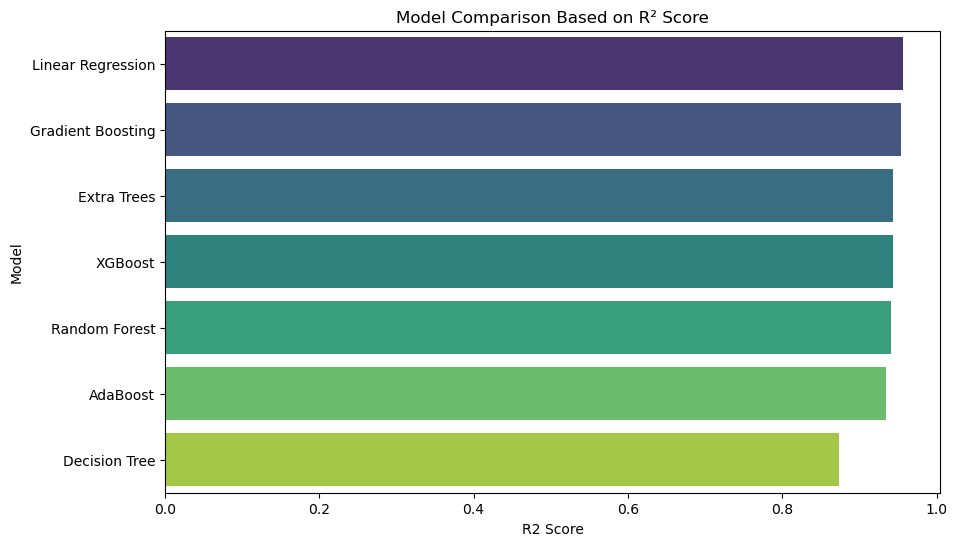

In [48]:
# R² Score Comparison
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.barplot(
    x="R2 Score",
    y="Model",
    data=results_df,
    palette="viridis"
)

plt.title("Model Comparison Based on R² Score")

plt.show()

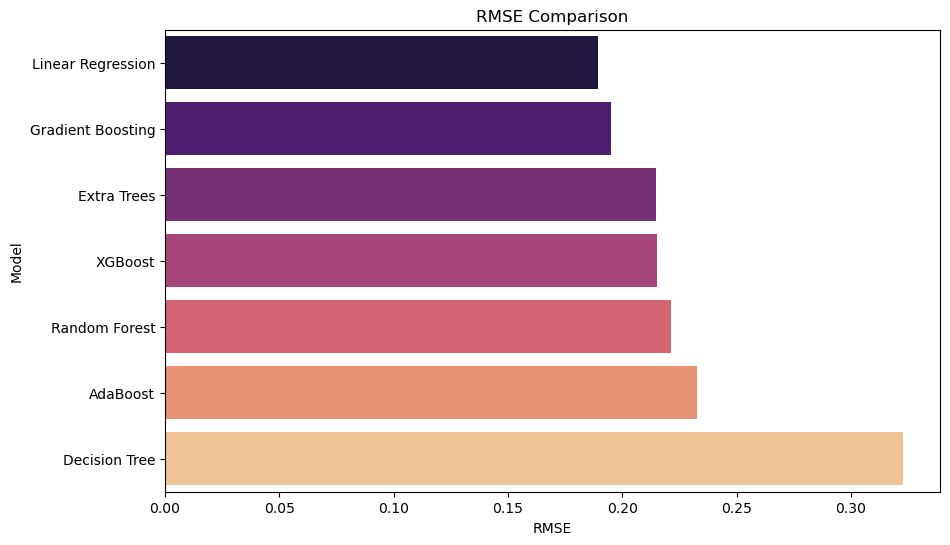

In [49]:
# RMSE Comparison
plt.figure(figsize=(10,6))

sns.barplot(
    x="RMSE",
    y="Model",
    data=results_df,
    palette="magma"
)

plt.title("RMSE Comparison")

plt.show()

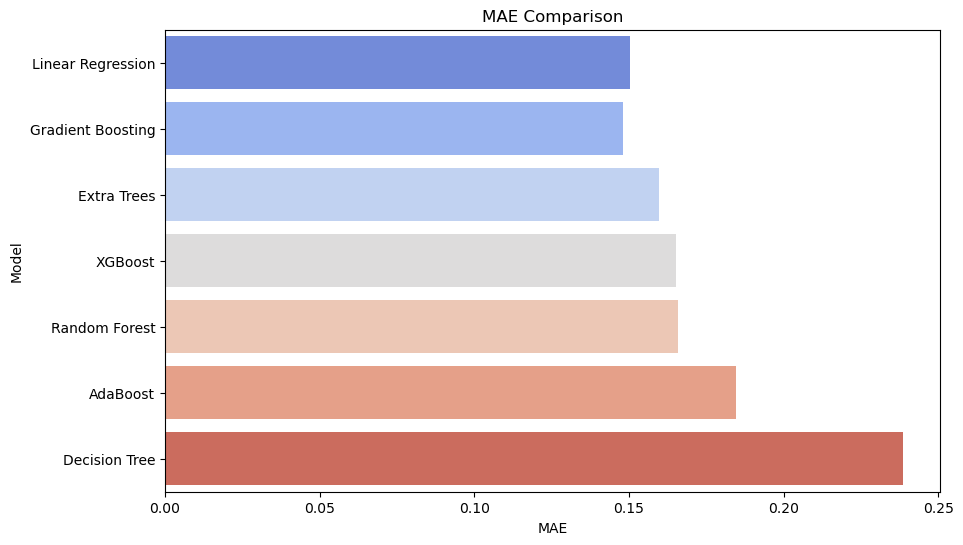

In [50]:
# MAE Comparison
plt.figure(figsize=(10,6))

sns.barplot(
    x="MAE",
    y="Model",
    data=results_df,
    palette="coolwarm"
)

plt.title("MAE Comparison")

plt.show()

In [52]:
#Select Best Model
best_model = models[best_model_name]

print(best_model)

LinearRegression()


In [53]:
# Save the Best Model
import joblib

joblib.dump(best_model, "student_performance_model.pkl")

print("Model Saved Successfully!")

Model Saved Successfully!


In [54]:
# Load the Saved Model
loaded_model = joblib.load("student_performance_model.pkl")

loaded_model

LinearRegression()

In [55]:
# Predict on Test Data
predictions = loaded_model.predict(X_test_scaled)

predictions[:10]

array([1.44802956, 2.98214116, 1.85395376, 3.56641831, 0.28198203,
       2.73496004, 1.65071383, 2.29634299, 2.12154492, 1.01745128])

In [56]:
#Actual vs Predicted Values
comparison = pd.DataFrame({
    "Actual GPA": y_test.values,
    "Predicted GPA": predictions
})

comparison.head(10)

,Actual GPA,Predicted GPA
0,1.427724,1.448030
1,3.117354,2.982141
2,2.037769,1.853954
3,3.548521,3.566418
4,0.248977,0.281982
5,2.627694,2.734960
6,2.057379,1.650714
7,2.248338,2.296343
8,2.194707,2.121545
9,0.758183,1.017451


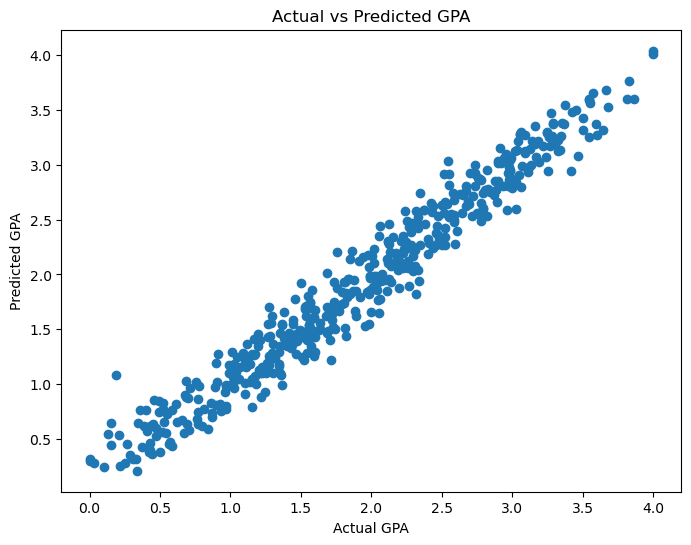

In [57]:
# Scatter Plot (Actual vs Predicted)
plt.figure(figsize=(8,6))

plt.scatter(y_test, predictions)

plt.xlabel("Actual GPA")
plt.ylabel("Predicted GPA")
plt.title("Actual vs Predicted GPA")

plt.show()

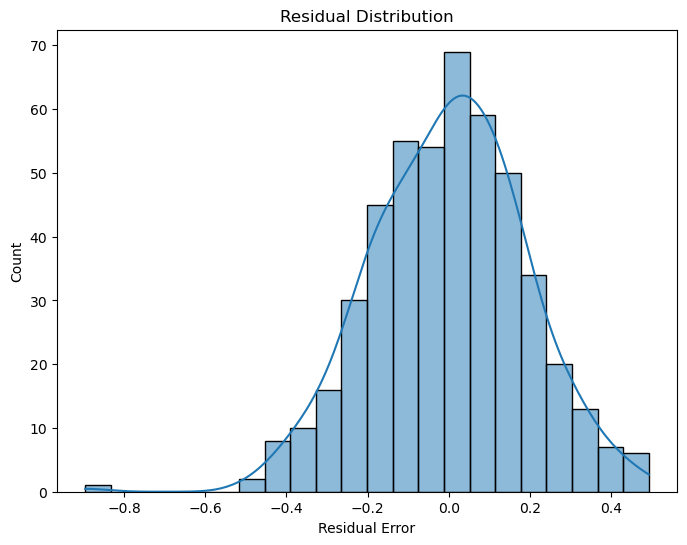

In [58]:
# Residual Plot
residuals = y_test - predictions

plt.figure(figsize=(8,6))

sns.histplot(residuals, kde=True)

plt.title("Residual Distribution")

plt.xlabel("Residual Error")

plt.show()

In [60]:
# Feature Importance (Tree-Based Models)
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": best_model.coef_
})

feature_importance["Absolute_Coefficient"] = feature_importance["Coefficient"].abs()

feature_importance = feature_importance.sort_values(
    by="Absolute_Coefficient",
    ascending=False
)

feature_importance

,Feature,Coefficient,Absolute_Coefficient
5,Absences,-0.796788,0.796788
14,AcademicSupport,0.132217,0.132217
6,Tutoring,0.130909,0.130909
11,Volunteering,-0.107870,0.107870
16,TotalEngagement,0.087134,0.087134
15,ActivityScore,0.078887,0.078887
4,StudyTimeWeekly,0.076312,0.076312
8,Extracurricular,0.070033,0.070033
9,Sports,0.066695,0.066695
12,GradeClass,-0.065805,0.065805


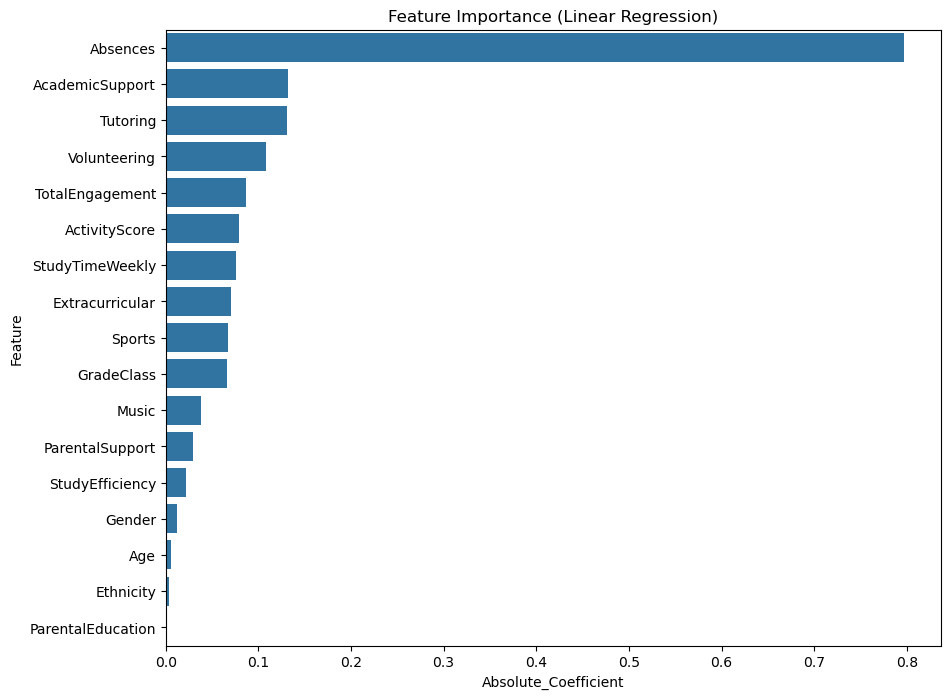

In [61]:
plt.figure(figsize=(10,8))

sns.barplot(
    data=feature_importance,
    x="Absolute_Coefficient",
    y="Feature"
)

plt.title("Feature Importance (Linear Regression)")
plt.show()

# Hyperparameter Tuning

In [62]:
from sklearn.model_selection import RandomizedSearchCV

In [63]:
#Random Forest Hyperparameter Tuning
rf = RandomForestRegressor(random_state=42)

param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 10, 20, 30, 40],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

In [64]:
# Apply RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid,
    n_iter=20,
    scoring='r2',
    cv=5,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train_scaled, y_train)

RandomizedSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'max_depth': [None, 10, 20, 30, 40],
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300, 500]},
                   random_state=42, scoring='r2')

In [65]:
print("Best Parameters:")
print(random_search.best_params_)

Best Parameters:
{'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}


In [66]:
print("Best Cross Validation Score:")
print(random_search.best_score_)

Best Cross Validation Score:
0.9436414681867689


In [67]:
best_rf = random_search.best_estimator_

best_rf

RandomForestRegressor(max_features='log2', min_samples_split=5,
                      n_estimators=300, random_state=42)

In [68]:
y_pred = best_rf.predict(X_test_scaled)

In [69]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 :", r2)

MAE : 0.1630081838328849
MSE : 0.04606341606365404
RMSE: 0.21462389443781427
R2 : 0.9442960462774735


In [70]:
import joblib

joblib.dump(best_rf, "best_student_model.pkl")

print("Best Model Saved Successfully!")

Best Model Saved Successfully!


In [71]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    best_rf,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='r2'
)

print(scores)

print("Average R2 Score:", scores.mean())

[0.94832424 0.94632209 0.93147819 0.95156978 0.94051304]
Average R2 Score: 0.9436414681867689


In [72]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance

,Feature,Importance
5,Absences,0.412979
12,GradeClass,0.267266
13,StudyEfficiency,0.193443
16,TotalEngagement,0.028700
4,StudyTimeWeekly,0.024795
14,AcademicSupport,0.021559
7,ParentalSupport,0.010495
15,ActivityScore,0.009015
6,Tutoring,0.006544
3,ParentalEducation,0.004799


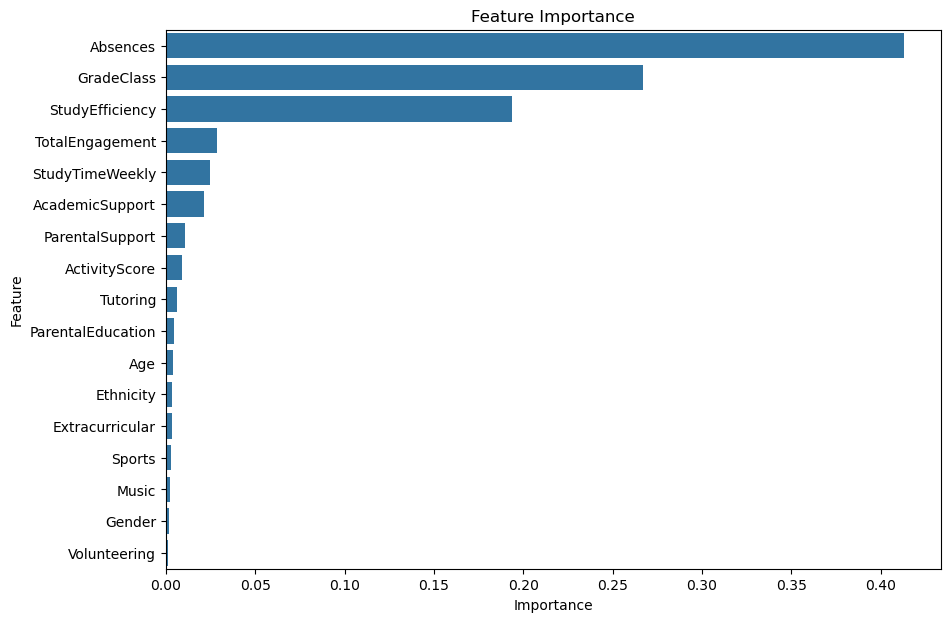

In [73]:
plt.figure(figsize=(10,7))

sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)

plt.title("Feature Importance")

plt.show()

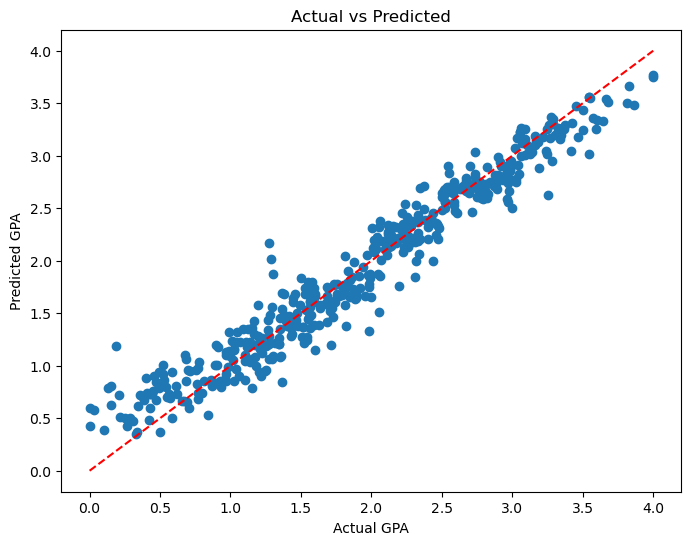

In [74]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual GPA")
plt.ylabel("Predicted GPA")

plt.title("Actual vs Predicted")

plt.show()

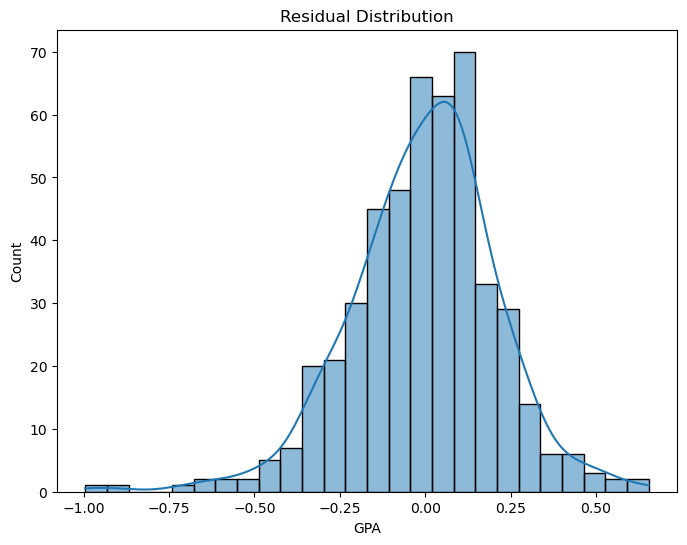

In [75]:
residuals = y_test - y_pred

plt.figure(figsize=(8,6))

sns.histplot(
    residuals,
    kde=True
)

plt.title("Residual Distribution")

plt.show()

In [76]:
summary = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R2 Score"],
    "Value": [mae, mse, rmse, r2]
})

summary

,Metric,Value
0,MAE,0.163008
1,MSE,0.046063
2,RMSE,0.214624
3,R2 Score,0.944296
